<a href="https://colab.research.google.com/github/WTFjarux/Level-6--Artificial-Intelligence/blob/main/2438454_SurajPandey_Worksheet9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Suraj Pandey

Student ID: 2438454

In [ ]:
pip install wordcloud

Import All Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("All libraries imported successfully!")

All libraries imported successfully!


Download NLTK Data

In [ ]:
# These download language data NLTK needs (only runs once)
nltk.download('stopwords')   # list of common words to remove (the, is, at...)
nltk.download('wordnet')     # dictionary for lemmatization (running → run)
nltk.download('omw-1.4')     # supporting data for wordnet

print("NLTK downloads done!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


NLTK downloads done!


Load Dataset

In [ ]:
# Google Drive:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# data = pd.read_csv('raw_data.csv')
data = pd.read_csv('/content/drive/MyDrive/Level 6 - Artificial Intelligence/Workshop 9/raw_data.csv')

print(f"Dataset Shape: {data.shape}")
print(f"\nFirst 5 rows:")
data.head()

Dataset Shape: (2689, 2)

First 5 rows:


,source,target
0,Who?,को?
1,Hide.,लुकाउनुहोस्।
2,Hide.,लुक।
3,Stay.,बस्नुहोस्।
4,Hello!,नमस्ते!


Explore the Dataset

In [ ]:
print(f"Column Names: {data.columns.tolist()}")
print(f"\nMissing Values:\n{data.isnull().sum()}")
print(f"\nTarget Value Counts:\n{data['target'].value_counts()}")

Column Names: ['source', 'target']

Missing Values:
source    0
target    0
dtype: int64

Target Value Counts:
target
के म रेडियो बन्द गर्न सक्छु?                      6
मलाई धेरै भोक लागेको छ।                           5
अलिक ठूलो बनाउनुहोस्।                             4
तिम्रो साथमा हुँदा मलाई खुसी लाग्छ।               4
हरेक वर्ष धेरै जापानीजहरु विदेश भ्रमण गर्दछन्।    4
                                                 ..
म टमको घर जाँदैछु।                                1
म भोलिको लागि तयार छु।                            1
म पक्का छु कि यो सत्य होइन।                       1
मलाई कुनै गुनासो छैन।                             1
म साँच्चै यसको कदर गर्छु।                         1
Name: count, Length: 2563, dtype: int64


Drop Missing Values

In [ ]:
data.dropna(subset=['source', 'target'], inplace=True)
data.reset_index(drop=True, inplace=True)

print(f"Dataset shape after dropping nulls: {data.shape}")

Dataset shape after dropping nulls: (2689, 2)


Text Cleaning Function

In [ ]:
def preprocess_text(text):
    # Lowercase
    text = str(text).lower()

    # Handle contractions
    contractions = {
        "don't": "do not", "can't": "cannot", "won't": "will not",
        "it's": "it is", "i'm": "i am", "i've": "i have",
        "i'll": "i will", "i'd": "i would", "you're": "you are",
        "they're": "they are", "we're": "we are", "isn't": "is not",
        "aren't": "are not", "wasn't": "was not", "weren't": "were not",
        "hasn't": "has not", "haven't": "have not", "didn't": "did not",
        "doesn't": "does not", "wouldn't": "would not", "couldn't": "could not",
        "shouldn't": "should not", "that's": "that is", "there's": "there is"
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions and hashtags
    text = re.sub(r'\@\w+|\#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(tokens)

print("Cleaning function defined!")

Cleaning function defined!


 Apply Cleaning to Dataset

In [ ]:
print("Cleaning text... please wait...")
data['cleaned_text'] = data['source'].apply(preprocess_text)

print("Done! Sample before & after cleaning:")
data[['source', 'target', 'cleaned_text']].head()

Cleaning text... please wait...
Done! Sample before & after cleaning:


,source,target,cleaned_text
0,Who?,को?,
1,Hide.,लुकाउनुहोस्।,hide
2,Hide.,लुक।,hide
3,Stay.,बस्नुहोस्।,stay
4,Hello!,नमस्ते!,hello


Encode Labels

In [ ]:
label_encoder = LabelEncoder()
data['sentiment_encoded'] = label_encoder.fit_transform(data['target'])

print(f"Label Classes : {label_encoder.classes_}")
print(f"Encoded Sample: {data['sentiment_encoded'].unique()}")
data[['target', 'sentiment_encoded']].head()

Label Classes : ['अँध्यारो हुनु अघि घर जाने प्रयास गर्नुहोस्।' 'अग्रिम भुक्तानी आवश्यक छ।'
 'अघिनै केक खाइसक्नु भयो?' ...
 '१० र १४ को बीचमा दुईवटा मात्र रुढ संख्याहरू छन्।' '३० मिनेट पर्खनुहोस्।'
 '९ बज्न ५ मिनेट बाँकी छ।']
Encoded Sample: [ 431 2404 2405 ... 2520 2439  823]


,target,sentiment_encoded
0,को?,431
1,लुकाउनुहोस्।,2404
2,लुक।,2405
3,बस्नुहोस्।,1380
4,नमस्ते!,1336


Word Cloud

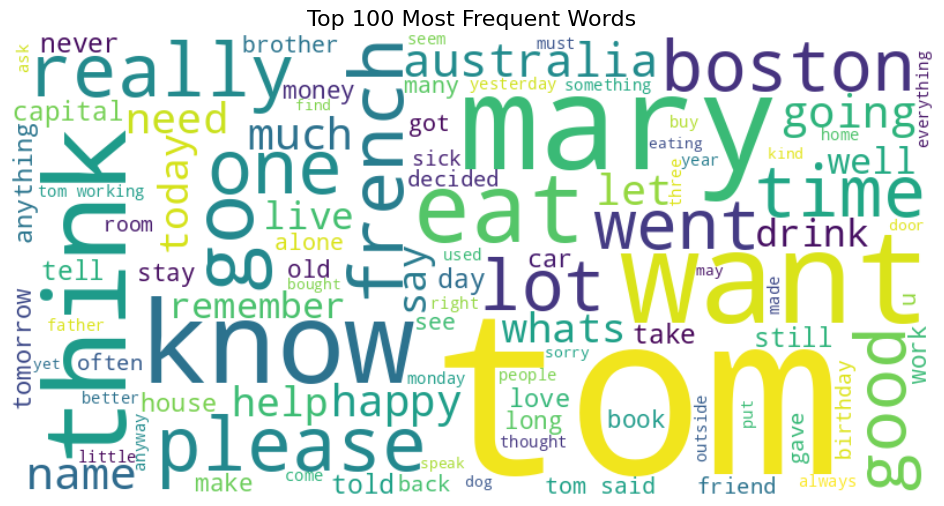

In [ ]:
all_words = ' '.join(data['cleaned_text'])

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words', fontsize=16)
plt.show()

Top 20 Words Bar Chart

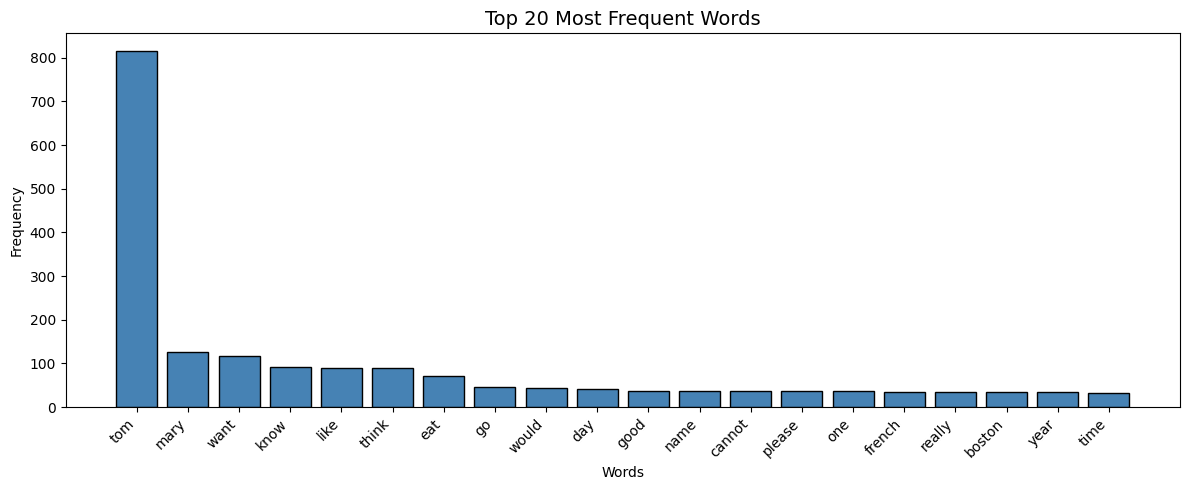

In [ ]:
word_list = all_words.split()
word_freq = Counter(word_list).most_common(20)
words, freqs = zip(*word_freq)

plt.figure(figsize=(12, 5))
plt.bar(words, freqs, color='steelblue', edgecolor='black')
plt.title('Top 20 Most Frequent Words', fontsize=14)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Sentiment Distribution Plot

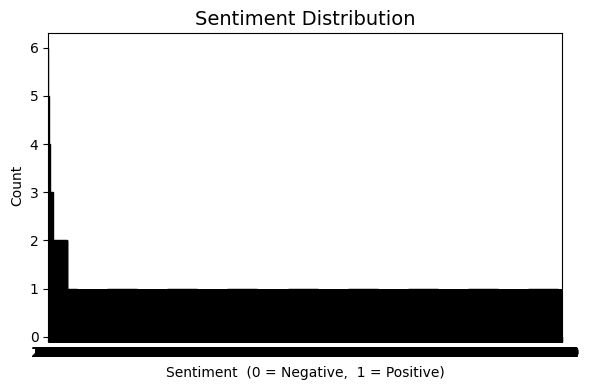

In [ ]:
plt.figure(figsize=(6, 4))
data['sentiment_encoded'].value_counts().plot(
    kind='bar', color=['tomato', 'steelblue'], edgecolor='black'
)
plt.title('Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment  (0 = Negative,  1 = Positive)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Train / Validation / Test Split

In [ ]:
# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    data['cleaned_text'],
    data['sentiment_encoded'],
    test_size=0.2,
    random_state=42
)

# Further split train → 90% train, 10% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42
)

print(f"Train size     : {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size      : {len(X_test)}")

Train size     : 1935
Validation size: 216
Test size      : 538


Tokenization

In [ ]:
VOCAB_SIZE = 10000

# Fit ONLY on training data to avoid data leakage
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

print(f"Vocabulary size : {len(tokenizer.word_index)}")
print(f"\nSample sequence : {X_train_seq[0]}")

Vocabulary size : 1473

Sample sequence : [2, 684, 144, 3, 125]


Sequence Length Distribution & Percentile Padding

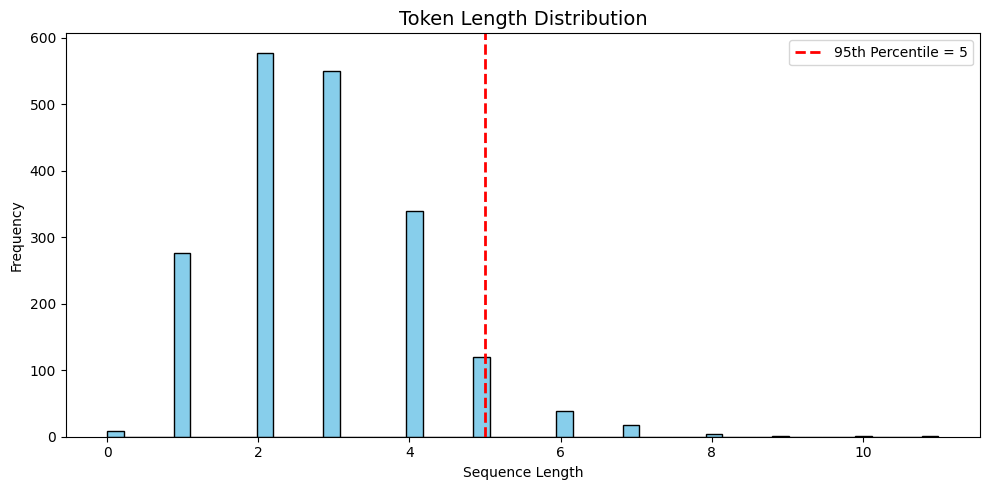

Max Length (95th percentile): 5


In [ ]:
seq_lengths = [len(seq) for seq in X_train_seq]

plt.figure(figsize=(10, 5))
plt.hist(seq_lengths, bins=50, color='skyblue', edgecolor='black')
p95 = int(np.percentile(seq_lengths, 95))
plt.axvline(p95, color='red', linestyle='dashed', linewidth=2,
            label=f'95th Percentile = {p95}')
plt.title('Token Length Distribution', fontsize=14)
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

MAX_LEN = p95
print(f"Max Length (95th percentile): {MAX_LEN}")

Apply Padding

In [ ]:
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

print(f"Train shape: {X_train_pad.shape}")
print(f"Val shape  : {X_val_pad.shape}")
print(f"Test shape : {X_test_pad.shape}")

Train shape: (1935, 5)
Val shape  : (216, 5)
Test shape : (538, 5)


Build Simple RNN Model

In [ ]:
EMBEDDING_DIM = 128
RNN_UNITS     = 64
NUM_CLASSES   = len(label_encoder.classes_)

rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(units=RNN_UNITS, return_sequences=False),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax') # Changed to NUM_CLASSES and softmax
])

rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy']) # Changed loss
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Build LSTM Model

In [ ]:
NUM_CLASSES   = len(label_encoder.classes_)

lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(units=RNN_UNITS, return_sequences=False),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax') # Changed to NUM_CLASSES and softmax
])

lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy']) # Changed loss
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train Simple RNN

In [ ]:
rnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_rnn.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=rnn_callbacks
)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 5.0816e-04 - loss: -2866.4857
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_rnn.keras

Epoch 1: finished saving model to best_rnn.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 5.1680e-04 - loss: -5866.2559 - val_accuracy: 0.0000e+00 - val_loss: -11252.0928
Epoch 2/10
29/31 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0005e-04 - loss: -12639.7490
Epoch 2: val_accuracy did not improve from 0.00000
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 5.1680e-04 - loss: -13601.6602 - val_accuracy: 0.0000e+00 - val_loss: -14926.4941
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0015 - loss: -16033.7400
Epoch 3: val_accuracy did not improve from 0.00000
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 5.1680e-04 - loss: -16938.5801 - val_accuracy: 0.0000e+00 - val_loss: -17843.0137
Epoch 4/10
28/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0000e+00 - loss: -191

Train LSTM

In [ ]:
lstm_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_lstm.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=lstm_callbacks
)

Epoch 1/10
29/31 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.8579e-05 - loss: -1197.2827
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_lstm.keras

Epoch 1: finished saving model to best_lstm.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 5.1680e-04 - loss: -3799.7397 - val_accuracy: 0.0000e+00 - val_loss: -11664.8076
Epoch 2/10
29/31 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.2250e-04 - loss: -14221.1819
Epoch 2: val_accuracy did not improve from 0.00000
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 5.1680e-04 - loss: -15977.2266 - val_accuracy: 0.0000e+00 - val_loss: -17866.8223
Epoch 3/10
30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 6.6517e-04 - loss: -19589.5644
Epoch 3: val_accuracy did not improve from 0.00000
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 5.1680e-04 - loss: -20152.1973 - val_accuracy: 0.0000e+00 - val_loss: -21072.1250
Epoch 4/10
28/31 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 4.0598e-05 - loss

 Evaluate Simple RNN

In [ ]:
y_pred_rnn = np.argmax(rnn_model.predict(X_test_pad), axis=-1)

# Get the unique integer labels present in both y_test and y_pred_rnn
all_observed_labels = np.unique(np.concatenate((y_test, y_pred_rnn)))

# Map these integer labels back to their original string names
# Only inverse transform for labels that actually appeared in the test set or predictions
all_observed_target_names = label_encoder.inverse_transform(all_observed_labels)

print("===== Simple RNN ====")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rnn)*100:.2f}%")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_rnn, labels=all_observed_labels)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_rnn, labels=all_observed_labels, target_names=all_observed_target_names, zero_division=0)}")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rnn, labels=all_observed_labels),
                       display_labels=all_observed_target_names).plot(cmap='Blues')
plt.title('Confusion Matrix — Simple RNN')
plt.show()

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
===== Simple RNN ====
Accuracy: 0.00%

Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report:
                                                                                        precision    recall  f1-score   support

                                           अँध्यारो हुनु अघि घर जाने प्रयास गर्नुहोस्।       0.00      0.00      0.00       0.0
                                                               अघिनै केक खाइसक्नु भयो?       0.00      0.00      0.00       1.0
                         अनुरोध गरे अनुसार, हामी हाम्रो अन्तिम प्रतिवेदन पेश गर्दैछौं।       0.00      0.00      0.00       0.0
                                          अन्तिम पटक मैले टमलाई अक्टोबरमा देखेको थिएँ।       0.00      0.00      0.00       0.0
                                                           अहिले हल्का टाउको दुखेको छ।       0.00      0.00      0.00  

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2305 (\N{DEVANAGARI SIGN CANDRABINDU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2343 (\N{DEVANAGARI LETTER DHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loca

KeyboardInterrupt: 

Evaluate LSTM

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
===== LSTM ====
Accuracy: 0.00%

Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report:
                                                                                        precision    recall  f1-score   support

                                                               अघिनै केक खाइसक्नु भयो?       0.00      0.00      0.00       1.0
                                                          अर्को हप्ता टमको जन्मदिन हो।       0.00      0.00      0.00       0.0
                                                              अहिलेसम्म के देख्नुभयो ?       0.00      0.00      0.00       1.0
                                                               आज मेरो पनि जन्मदिन हो।       0.00      0.00      0.00       1.0
                                                 आजकल धेरै कम्पनीहरूले त्यसो गर्नेछन्।       0.00      0.00      0.00       

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2328 (\N{DEVANAGARI LETTER GHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2367 (\N{DEVANAGARI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/

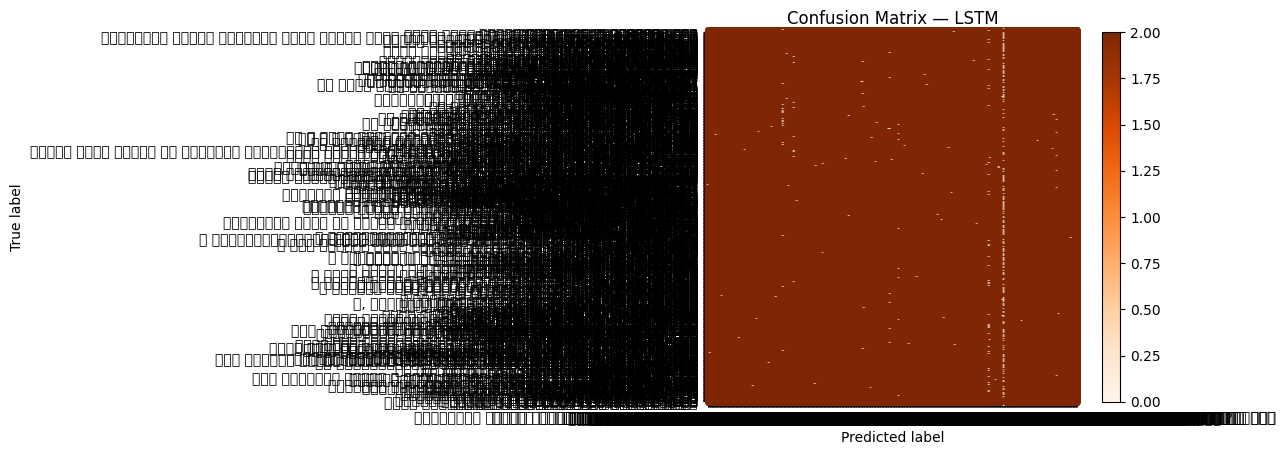

In [ ]:
y_pred_lstm = np.argmax(lstm_model.predict(X_test_pad), axis=-1)

# Get the unique integer labels present in both y_test and y_pred_lstm
all_observed_labels = np.unique(np.concatenate((y_test, y_pred_lstm)))

# Map these integer labels back to their original string names
# Only inverse transform for labels that actually appeared in the test set or predictions
all_observed_target_names = [label_encoder.classes_[label] for label in all_observed_labels]

print("===== LSTM ====")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lstm)*100:.2f}%")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_lstm, labels=all_observed_labels)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_lstm, labels=all_observed_labels, target_names=all_observed_target_names, zero_division=0)}")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lstm, labels=all_observed_labels),
                       display_labels=all_observed_target_names).plot(cmap='Oranges')
plt.title('Confusion Matrix — LSTM')
plt.show()

Plot Training Curves

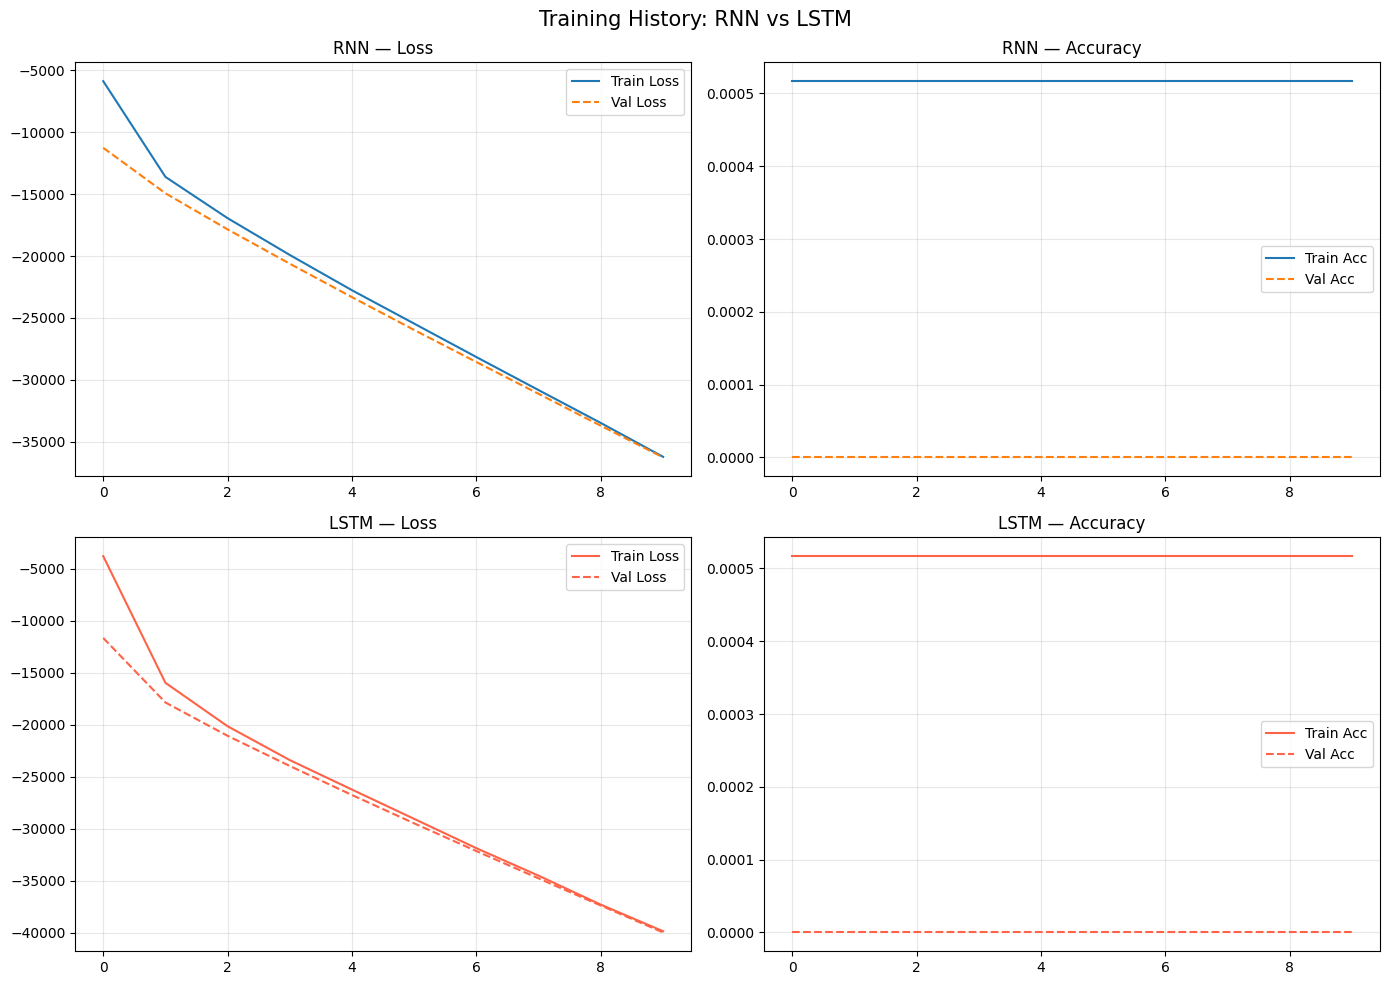

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training History: RNN vs LSTM', fontsize=15)

# RNN Loss
axes[0][0].plot(rnn_history.history['loss'],     label='Train Loss')
axes[0][0].plot(rnn_history.history['val_loss'], label='Val Loss', linestyle='--')
axes[0][0].set_title('RNN — Loss')
axes[0][0].legend()
axes[0][0].grid(True, alpha=0.3)

# RNN Accuracy
axes[0][1].plot(rnn_history.history['accuracy'],     label='Train Acc')
axes[0][1].plot(rnn_history.history['val_accuracy'], label='Val Acc', linestyle='--')
axes[0][1].set_title('RNN — Accuracy')
axes[0][1].legend()
axes[0][1].grid(True, alpha=0.3)

# LSTM Loss
axes[1][0].plot(lstm_history.history['loss'],     label='Train Loss', color='tomato')
axes[1][0].plot(lstm_history.history['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
axes[1][0].set_title('LSTM — Loss')
axes[1][0].legend()
axes[1][0].grid(True, alpha=0.3)

# LSTM Accuracy
axes[1][1].plot(lstm_history.history['accuracy'],     label='Train Acc', color='tomato')
axes[1][1].plot(lstm_history.history['val_accuracy'], label='Val Acc',   color='tomato', linestyle='--')
axes[1][1].set_title('LSTM — Accuracy')
axes[1][1].legend()
axes[1][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

RNN vs LSTM Final Comparison

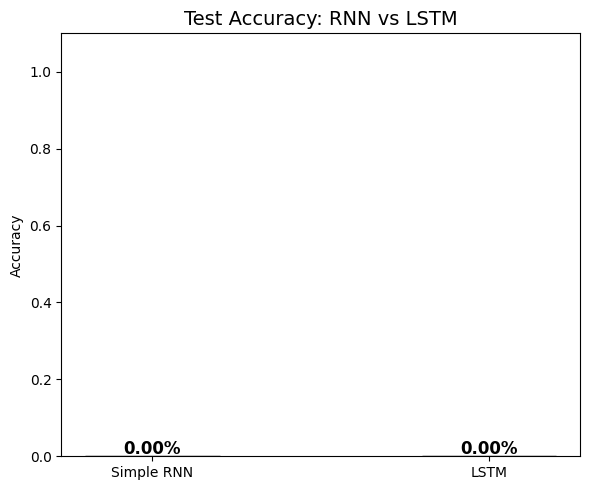

Simple RNN Accuracy : 0.00%
LSTM Accuracy       : 0.00%


In [ ]:
rnn_acc  = accuracy_score(y_test, y_pred_rnn)
lstm_acc = accuracy_score(y_test, y_pred_lstm)

plt.figure(figsize=(6, 5))
bars = plt.bar(['Simple RNN', 'LSTM'], [rnn_acc, lstm_acc],
               color=['royalblue', 'tomato'], edgecolor='black', width=0.4)
for bar, acc in zip(bars, [rnn_acc, lstm_acc]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{acc*100:.2f}%',
             ha='center', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.title('Test Accuracy: RNN vs LSTM', fontsize=14)
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

print(f"Simple RNN Accuracy : {rnn_acc*100:.2f}%")
print(f"LSTM Accuracy       : {lstm_acc*100:.2f}%")

Real-Time Prediction Function

In [ ]:
def predict_sentiment(text, model, model_name="Model"):
    cleaned  = preprocess_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    # For multi-class, predict returns probabilities for each class
    predictions = model.predict(padded, verbose=0)[0]
    predicted_class_index = np.argmax(predictions)
    confidence = predictions[predicted_class_index]

    # To convert back to original label, use label_encoder.inverse_transform
    predicted_label = label_encoder.inverse_transform([predicted_class_index])

    print(f"[{model_name}] → Predicted Label: {predicted_label[0]} (Confidence: {confidence*100:.2f}%) ")
    return predicted_label[0]

# Test it
test_tweet = "I love this product, it is absolutely amazing!"
predict_sentiment(test_tweet, rnn_model,  "Simple RNN")
predict_sentiment(test_tweet, lstm_model, "LSTM")

[Simple RNN] → Predicted Label: के म यो रोटी खान सक्छु? (Confidence: 0.04%) 
[LSTM] → Predicted Label: तपाईंले मजाक गरेको हुनु पर्छ! (Confidence: 0.04%) 


'तपाईंले मजाक गरेको हुनु पर्छ!'